## Name: Shivam Kumar





## Question 1:

To understand and implement the basic working of an artificial neuron using Python.

In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [2]:
def artificial_neuron(inputs, weights, bias):
    weighted_sum = np.dot(inputs, weights)
    z = weighted_sum + bias
    output = sigmoid(z)
    return weighted_sum, z, output

In [3]:
inputs = np.array([0.7, 0.2, 0.9])
weights = np.array([0.5, -0.4, 0.8])
bias = 0.1

weighted_sum, z, output = artificial_neuron(inputs, weights, bias)

print("Inputs:", inputs)
print("Weights:", weights)
print("Bias:", bias)
print("Weighted sum:", round(float(z), 4))
print("Neuron output using sigmoid:", round(float(output), 4))

Inputs: [0.7 0.2 0.9]
Weights: [ 0.5 -0.4  0.8]
Bias: 0.1
Weighted sum: 1.09
Neuron output using sigmoid: 0.7484


In [4]:
test_cases = [
    np.array([0.2, 0.4, 0.6]),
    np.array([0.9, 0.1, 0.8]),
    np.array([-0.3, 0.5, 0.7]),
]

for i, sample in enumerate(test_cases, start=1):
    _, z, y = artificial_neuron(sample, weights, bias)
    print(f"Test {i}: input={sample}, weighted_sum={z:.4f}, output={y:.4f}")

Test 1: input=[0.2 0.4 0.6], weighted_sum=0.5200, output=0.6271
Test 2: input=[0.9 0.1 0.8], weighted_sum=1.1500, output=0.7595
Test 3: input=[-0.3  0.5  0.7], weighted_sum=0.3100, output=0.5769


---

## Question 2:

To implement the weighted sum of inputs and bias used in an artificial neuron using Python.

In [5]:
import numpy as np

def calculate_weighted_sum(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

In [6]:
inputs = np.array([2.0, 4.0, 6.0])
weights = np.array([0.3, 0.5, -0.2])
bias = 1.0

contributions = inputs * weights
weighted_sum = calculate_weighted_sum(inputs, weights, bias)

print("Input x Weight contributions:", contributions)
print("Bias:", bias)
print("Weighted sum = sum(inputs * weights) + bias")
print("Weighted sum:", round(float(weighted_sum), 4))

Input x Weight contributions: [ 0.6  2.  -1.2]
Bias: 1.0
Weighted sum = sum(inputs * weights) + bias
Weighted sum: 2.4


In [7]:
X = np.array([
    [1.0, 0.5, -1.0],
    [0.2, 0.8, 0.3],
    [-0.4, -0.6, 0.9],
])
w = np.array([0.5, -0.2, 0.7])
b = 0.1

print("Batch example:")
for i, row in enumerate(X, start=1):
    print(f"Sample {i}: z = {calculate_weighted_sum(row, w, b):.4f}")

Batch example:
Sample 1: z = -0.2000
Sample 2: z = 0.2500
Sample 3: z = 0.6500


---

## Question 3:

To implement and visualize Sigmoid, Tanh, and ReLU activation functions using Python.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

In [9]:
sample_values = [-2, 0, 2]
print("Sample activation values:")
for value in sample_values:
    print(
        f"x={value:>2}: sigmoid={sigmoid(value):.4f}, "
        f"tanh={tanh(value):.4f}, relu={relu(value):.4f}"
    )

Sample activation values:
x=-2: sigmoid=0.1192, tanh=-0.9640, relu=0.0000
x= 0: sigmoid=0.5000, tanh=0.0000, relu=0.0000
x= 2: sigmoid=0.8808, tanh=0.9640, relu=2.0000


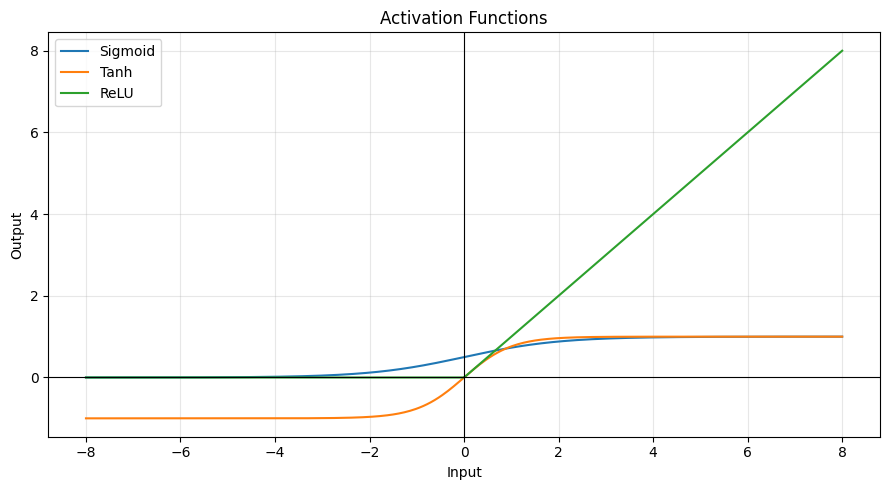

Activation function graph saved to outputs\activation_functions.png


In [10]:
x = np.linspace(-8, 8, 400)

plt.figure(figsize=(9, 5))
plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, tanh(x), label="Tanh")
plt.plot(x, relu(x), label="ReLU")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

output_path = OUTPUT_DIR / "activation_functions.png"
plt.savefig(output_path, dpi=150)
plt.show()
print(f"Activation function graph saved to {output_path}")

---

## Question 4:

To create a simple single-layer neural network using Python.

In [11]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class SingleLayerNetwork:
    def __init__(self):
        self.weights = np.array([[0.2, -0.3], [0.4, 0.1], [-0.5, 0.6]])
        self.bias = np.zeros(2)

    def forward(self, x):
        return sigmoid(np.dot(x, self.weights) + self.bias)

In [12]:
X = np.array([
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0],
    [1.0, 1.0, 0.0],
])

network = SingleLayerNetwork()
predictions = network.forward(X)

print("Input samples:\n", X)
print("Network output:\n", np.round(predictions, 4))

Input samples:
 [[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 0.]]
Network output:
 [[0.4256 0.5744]
 [0.475  0.6682]
 [0.6457 0.4502]]


In [13]:
new_sample = np.array([[0.5, 0.8, 0.3]])
print("New sample:", new_sample)
print("Predicted output:", np.round(network.forward(new_sample), 4))

New sample: [[0.5 0.8 0.3]]
Predicted output: [[0.5671 0.5275]]


---

## Question 5:

To create a Multilayer Perceptron (MLP) with input, hidden, and output layers using Keras/TensorFlow.

In [14]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(8, activation="relu", name="hidden_layer"),
    tf.keras.layers.Dense(3, activation="softmax", name="output_layer"),
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
prediction = model.predict(sample, verbose=0)
print("Prediction probabilities before training:", np.round(prediction, 4))

Prediction probabilities before training: [[0.0061 0.1059 0.888 ]]


---

## Question 6:

To apply Gradient Descent for updating the weights of a simple neural network during training.

In [2]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [3]:
x = np.array([1.0, 2.0])
y_true = 1.0
weights = np.array([0.1, -0.2])
bias = 0.0
learning_rate = 0.1

for epoch in range(1, 11):
    z = np.dot(x, weights) + bias
    y_pred = sigmoid(z)
    error = y_pred - y_true

    dz = error * y_pred * (1 - y_pred)
    dw = dz * x
    db = dz

    weights -= learning_rate * dw
    bias -= learning_rate * db
    loss = 0.5 * (y_true - y_pred) ** 2

    print(
        f"Epoch {epoch:02d} | loss={loss:.5f} | prediction={y_pred:.5f} "
        f"| weights={np.round(weights, 4)} | bias={bias:.4f}"
    )

Epoch 01 | loss=0.16499 | prediction=0.42556 | weights=[ 0.114  -0.1719] | bias=0.0140
Epoch 02 | loss=0.15331 | prediction=0.44627 | weights=[ 0.1277 -0.1445] | bias=0.0277
Epoch 03 | loss=0.14224 | prediction=0.46664 | weights=[ 0.141 -0.118] | bias=0.0410
Epoch 04 | loss=0.13184 | prediction=0.48650 | weights=[ 0.1538 -0.0923] | bias=0.0538
Epoch 05 | loss=0.12215 | prediction=0.50574 | weights=[ 0.1662 -0.0676] | bias=0.0662
Epoch 06 | loss=0.11317 | prediction=0.52426 | weights=[ 0.178  -0.0439] | bias=0.0780
Epoch 07 | loss=0.10489 | prediction=0.54197 | weights=[ 0.1894 -0.0212] | bias=0.0894
Epoch 08 | loss=0.09730 | prediction=0.55885 | weights=[0.2003 0.0006] | bias=0.1003
Epoch 09 | loss=0.09037 | prediction=0.57488 | weights=[0.2107 0.0214] | bias=0.1107
Epoch 10 | loss=0.08404 | prediction=0.59003 | weights=[0.2206 0.0412] | bias=0.1206


---

## Question 7:

To understand and implement the basic concept of Backpropagation for training a neural network.

In [19]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative_from_output(y):
    return y * (1 - y)

def binary_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [20]:
np.random.seed(42)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

w1 = np.random.randn(2, 3) * 0.5
b1 = np.zeros((1, 3))
w2 = np.random.randn(3, 1) * 0.5
b2 = np.zeros((1, 1))
lr = 0.8

In [21]:
for epoch in range(1, 5001):
    hidden = sigmoid(X @ w1 + b1)
    output = sigmoid(hidden @ w2 + b2)

    d_output = output - y
    d_w2 = hidden.T @ d_output / len(X)
    d_b2 = np.mean(d_output, axis=0, keepdims=True)

    d_hidden = (d_output @ w2.T) * sigmoid_derivative_from_output(hidden)
    d_w1 = X.T @ d_hidden / len(X)
    d_b1 = np.mean(d_hidden, axis=0, keepdims=True)

    w2 -= lr * d_w2
    b2 -= lr * d_b2
    w1 -= lr * d_w1
    b1 -= lr * d_b1

    if epoch in (1, 1000, 3000, 5000):
        print(f"Epoch {epoch:04d} | loss={binary_cross_entropy(y, output):.5f}")

predictions = (output >= 0.5).astype(int)
print("Final probabilities:\n", np.round(output, 4))
print("Final XOR predictions:\n", predictions)

Epoch 0001 | loss=0.72978
Epoch 1000 | loss=0.02609
Epoch 3000 | loss=0.00483
Epoch 5000 | loss=0.00262
Final probabilities:
 [[0.0031]
 [0.9976]
 [0.9976]
 [0.0025]]
Final XOR predictions:
 [[0]
 [1]
 [1]
 [0]]


---

## Question 8:

To train a simple neural network model on a dataset using Keras/TensorFlow.

In [22]:
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

np.random.seed(42)
tf.random.set_seed(42)

In [23]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
target_names = [str(name) for name in iris.target_names]

In [24]:
iris_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax"),
])

iris_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = iris_model.fit(X_train, y_train, epochs=80, batch_size=8, validation_split=0.1, verbose=0)
loss, accuracy = iris_model.evaluate(X_test, y_test, verbose=0)
iris_model.save(OUTPUT_DIR / "iris_ann_model.keras")

print("Classes:", target_names)
print("Final training accuracy:", round(history.history["accuracy"][-1], 4))
print("Test loss:", round(loss, 4))
print("Test accuracy:", round(accuracy, 4))
print("Saved model:", OUTPUT_DIR / "iris_ann_model.keras")

Classes: ['setosa', 'versicolor', 'virginica']
Final training accuracy: 0.963
Test loss: 0.118
Test accuracy: 0.9667
Saved model: outputs\iris_ann_model.keras


---

## Question 9:

To evaluate the performance of a trained neural network using suitable evaluation metrics in Python.

In [25]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
probabilities = iris_model.predict(X_test, verbose=0)
y_pred = np.argmax(probabilities, axis=1)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9667
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



---

## Question 10:

To design, train, and evaluate a complete Artificial Neural Network-based classification system using Python and Keras/TensorFlow by integrating input features, hidden layers, activation functions, training, prediction, and evaluation.

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

np.random.seed(42)
tf.random.set_seed(42)

In [28]:
data = load_breast_cancer()
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target
)

scaler = StandardScaler()
X_train_bc = scaler.fit_transform(X_train_bc)
X_test_bc = scaler.transform(X_test_bc)

In [29]:
bc_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_bc.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

bc_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

bc_history = bc_model.fit(
    X_train_bc, y_train_bc, epochs=60, batch_size=16, validation_split=0.15, verbose=0
)

In [30]:
probabilities = bc_model.predict(X_test_bc, verbose=0).ravel()
predictions = (probabilities >= 0.5).astype(int)
accuracy = accuracy_score(y_test_bc, predictions)

print("Dataset: Breast Cancer Wisconsin Diagnostic Dataset")
print("Input features:", X_train_bc.shape[1])
print("Hidden layers: Dense(16, ReLU), Dense(8, ReLU)")
print("Output layer: Dense(1, Sigmoid)")
print("Test accuracy:", round(accuracy, 4))
print("Confusion Matrix:\n", confusion_matrix(y_test_bc, predictions))
print("Classification Report:\n", classification_report(y_test_bc, predictions, target_names=data.target_names))

Dataset: Breast Cancer Wisconsin Diagnostic Dataset
Input features: 30
Hidden layers: Dense(16, ReLU), Dense(8, ReLU)
Output layer: Dense(1, Sigmoid)
Test accuracy: 0.9649
Confusion Matrix:
 [[41  1]
 [ 3 69]]
Classification Report:
               precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



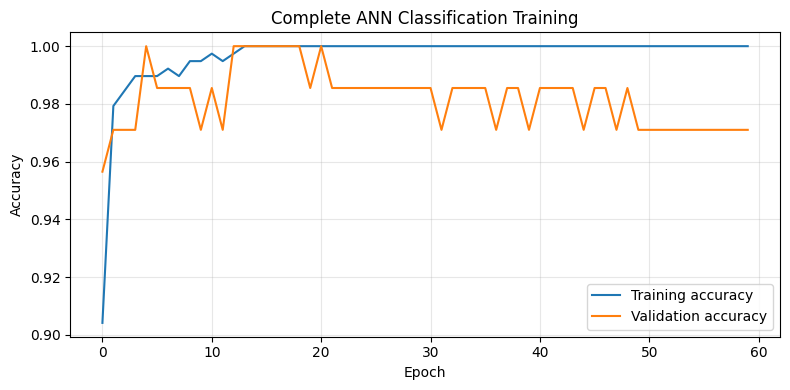

Training graph saved: outputs\complete_ann_training_accuracy.png
Model saved: outputs\breast_cancer_ann_model.keras


In [31]:
plt.figure(figsize=(8, 4))
plt.plot(bc_history.history["accuracy"], label="Training accuracy")
plt.plot(bc_history.history["val_accuracy"], label="Validation accuracy")
plt.title("Complete ANN Classification Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plot_path = OUTPUT_DIR / "complete_ann_training_accuracy.png"
plt.savefig(plot_path, dpi=150)
plt.show()

bc_model.save(OUTPUT_DIR / "breast_cancer_ann_model.keras")
print("Training graph saved:", plot_path)
print("Model saved:", OUTPUT_DIR / "breast_cancer_ann_model.keras")

---